# Reshaping DataFrames

Subtitle: **How to reshape the layout of tables**.

For more information see the user guide section on [Reshaping](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html).

In [21]:
import pandas as pd

## Data Formats

A dataset can be written in two different formats: wide and long.

- A **wide** format contains values that do not repeat in the first column.
- A **long** format contains values that do repeat in the first column.

For example, consider the following two datasets that contain the exact same data expressed in different formats:

![](../assets/pandas/wide_vs_long.png)

Both datasets contain the exact same information about the teams, but they’re simply expressed in different formats.

## Long to wide table format

In [22]:
df = pd.DataFrame(
    {
        "team":   ["A", "A", "A", "A", "B", "B", "B", "B"],
        "player": [  1,   2,   3,   4,   1,   2,   3,   4],
        "points": [ 11,   8,  10,   6,  12,   5,   9,   4],
    }
)
df

,team,player,points
0,A,1,11
1,A,2,8
2,A,3,10
3,A,4,6
4,B,1,12
5,B,2,5
6,B,3,9
7,B,4,4


The [`pivot()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot.html#pandas.pivot "pandas.pivot") function is purely reshaping of the data: a single value for each index/column combination is required.

We can use the following basic syntax to convert a pandas DataFrame from a long format to a wide format:


In [23]:
pd.pivot(df, index='player', columns='team', values='points')

team,A,B
player,,
1,11,12
2,8,5
3,10,9
4,6,4


## Wide to long format

Starting again from the wide format table created in the previous section, we add a new index to the `DataFrame` with [`reset_index()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.reset_index.html#pandas.DataFrame.reset_index "pandas.DataFrame.reset_index"), and use [`melt()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html#pandas.melt) to make  the column headers, the variable names in a newly created column.

In [24]:
pivoted = pd.pivot(df, index='team', columns='player', values='points')
pivoted.reset_index().melt(id_vars=['team'], var_name='player', value_name='points')

,team,player,points
0,A,1,11
1,B,1,12
2,A,2,8
3,B,2,5
4,A,3,10
5,B,3,9
6,A,4,6
7,B,4,4


## Air Quality Data

The air-quality data is provided in a so-called **long format** data representation with each observation on a separate row and each variable a separate column of the data table. The long/narrow format is also known as the [tidy data format](https://www.jstatsoft.org/article/view/v059i10).

Let's load it into `air_quality` DataFrame:

In [25]:
url = "https://github.com/pandas-dev/pandas/blob/main/doc/data/air_quality_long.csv"
air_quality = pd.read_csv(
    url.replace("blob", "raw"),
    index_col="date.utc",
    parse_dates=True
)
air_quality.head()

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-18 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.0,µg/m³
2019-06-17 08:00:00+00:00,Antwerpen,BE,BETR801,pm25,6.5,µg/m³
2019-06-17 07:00:00+00:00,Antwerpen,BE,BETR801,pm25,18.5,µg/m³
2019-06-17 06:00:00+00:00,Antwerpen,BE,BETR801,pm25,16.0,µg/m³
2019-06-17 05:00:00+00:00,Antwerpen,BE,BETR801,pm25,7.5,µg/m³


> The air-quality data set has the following columns:
> 
> - `city`: city where the sensor is used, either Paris, Antwerp or London
> - `country`: country where the sensor is used, either FR, BE or GB
> - `location`: the id of the sensor, either _FR04014_, _BETR801_ or _London Westminster_
> - `parameter`: the parameter measured by the sensor, either 𝑁⁢𝑂2 or Particulate matter
> - `value`: the measured value
> - `unit`: the unit of the measured parameter, in this case ‘µg/m³’
>     
> and the index of the `DataFrame` is `datetime`, the datetime of the measurement.

Keep in mind that we have 2 parameters:

In [26]:
air_quality["parameter"].value_counts()

parameter
no2     3447
pm25    1825
Name: count, dtype: int64

Let's focus on $NO2$ data:

In [27]:
no2 = air_quality[air_quality["parameter"] == "no2"]
no2.head()

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-21 00:00:00+00:00,Paris,FR,FR04014,no2,20.0,µg/m³
2019-06-20 23:00:00+00:00,Paris,FR,FR04014,no2,21.8,µg/m³
2019-06-20 22:00:00+00:00,Paris,FR,FR04014,no2,26.5,µg/m³
2019-06-20 21:00:00+00:00,Paris,FR,FR04014,no2,24.9,µg/m³
2019-06-20 20:00:00+00:00,Paris,FR,FR04014,no2,21.4,µg/m³


Now we want the values for the 3 stations as separate columns next to each other. The pivot will do the transformation shown in the depiction below:

![](../assets/pandas/07_pivot.png)

In [28]:
no2_pivoted = no2.pivot(columns="location", values="value")
no2_pivoted

location,BETR801,FR04014,London Westminster
date.utc,,,
2019-04-09 01:00:00+00:00,22.5,24.4,NaN
2019-04-09 02:00:00+00:00,53.5,27.4,67.0
2019-04-09 03:00:00+00:00,54.5,34.2,67.0
2019-04-09 04:00:00+00:00,34.5,48.5,41.0
2019-04-09 05:00:00+00:00,46.5,59.5,41.0
...,...,...,...
2019-06-20 20:00:00+00:00,NaN,21.4,NaN
2019-06-20 21:00:00+00:00,NaN,24.9,NaN
2019-06-20 22:00:00+00:00,NaN,26.5,NaN


As pandas supports plotting of multiple columns out of the box, the conversion from **long** to **wide** table format **enables the plotting of the different time series at the same time**:

<Axes: xlabel='date.utc'>

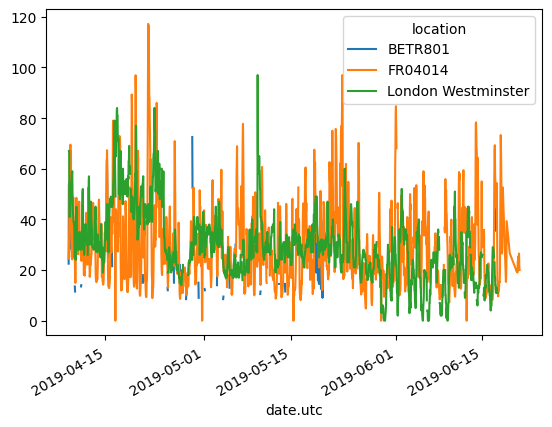

In [29]:
no2_pivoted.plot()

Let's say we want the mean concentrations for $NO2$ and $PM2.5$ in each of the stations in table form.

In the case of [`pivot()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot.html#pandas.DataFrame.pivot "pandas.DataFrame.pivot"), the data is only rearranged. When multiple values need to be aggregated (in this specific case, the values on different time steps), [`pivot_table()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot_table.html#pandas.DataFrame.pivot_table "pandas.DataFrame.pivot_table") can be used, providing an aggregation function (e.g. mean) on how to combine these values.

In [30]:
air_quality.pivot_table(
    values="value",
    index="location",
    columns="parameter",
    aggfunc="mean",
)

parameter,no2,pm25
location,,
BETR801,26.950920,23.169492
FR04014,29.374284,NaN
London Westminster,29.740050,13.443568


Pivot table is a well known concept in spreadsheet software. When interested in the row/column margins (subtotals) for each variable, set the `margins` parameter to `True`:

In [31]:
air_quality.pivot_table(
    values="value",
    index="location",
    columns="parameter",
    aggfunc="mean",
    margins=True,
)

parameter,no2,pm25,All
location,,,
BETR801,26.950920,23.169492,24.982353
FR04014,29.374284,NaN,29.374284
London Westminster,29.740050,13.443568,21.491708
All,29.430316,14.386849,24.222743


In case you are wondering, [`pivot_table()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.pivot_table.html#pandas.DataFrame.pivot_table "pandas.DataFrame.pivot_table") is indeed directly linked to [`groupby()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.groupby.html#pandas.DataFrame.groupby "pandas.DataFrame.groupby"). The same result can be derived by grouping on both `parameter` and `location`:

In [32]:
air_quality.groupby(["parameter", "location"])[["value"]].mean()

value
parameter location                     
no2       BETR801             26.950920
          FR04014             29.374284
          London Westminster  29.740050
pm25      BETR801             23.169492
          London Westminster  13.443568

### Wide to long format

Starting again from the wide format table created in the previous section:

In [33]:
# Original DataFrame
no2.head()

,city,country,location,parameter,value,unit
date.utc,,,,,,
2019-06-21 00:00:00+00:00,Paris,FR,FR04014,no2,20.0,µg/m³
2019-06-20 23:00:00+00:00,Paris,FR,FR04014,no2,21.8,µg/m³
2019-06-20 22:00:00+00:00,Paris,FR,FR04014,no2,26.5,µg/m³
2019-06-20 21:00:00+00:00,Paris,FR,FR04014,no2,24.9,µg/m³
2019-06-20 20:00:00+00:00,Paris,FR,FR04014,no2,21.4,µg/m³


Let's pivot the DataFrame:

In [34]:
no2_pivoted = no2.pivot(
    columns="location",
    values="value"
)
no2_pivoted.head()

location,BETR801,FR04014,London Westminster
date.utc,,,
2019-04-09 01:00:00+00:00,22.5,24.4,NaN
2019-04-09 02:00:00+00:00,53.5,27.4,67.0
2019-04-09 03:00:00+00:00,54.5,34.2,67.0
2019-04-09 04:00:00+00:00,34.5,48.5,41.0
2019-04-09 05:00:00+00:00,46.5,59.5,41.0


Let's add a new index to the `DataFrame` with [`reset_index()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.reset_index.html#pandas.DataFrame.reset_index "pandas.DataFrame.reset_index"):

In [35]:
no2_pivoted = no2_pivoted.reset_index()
no2_pivoted.head()

location,date.utc,BETR801,FR04014,London Westminster
0,2019-04-09 01:00:00+00:00,22.5,24.4,NaN
1,2019-04-09 02:00:00+00:00,53.5,27.4,67.0
2,2019-04-09 03:00:00+00:00,54.5,34.2,67.0
3,2019-04-09 04:00:00+00:00,34.5,48.5,41.0
4,2019-04-09 05:00:00+00:00,46.5,59.5,41.0


Let's say now we want to collect all air quality $NO2$ measurements in a single column (long format). The parameters passed to [`pandas.melt()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.melt.html#pandas.melt "pandas.melt") can be defined in more detail:

In [36]:
no_2 = no2_pivoted.melt(
    id_vars="date.utc",
    var_name="id_location",
    value_vars=["BETR801", "FR04014", "London Westminster"],
    value_name="NO_2",
).set_index("date.utc")
no_2.head()

,id_location,NO_2
date.utc,,
2019-04-09 01:00:00+00:00,BETR801,22.5
2019-04-09 02:00:00+00:00,BETR801,53.5
2019-04-09 03:00:00+00:00,BETR801,54.5
2019-04-09 04:00:00+00:00,BETR801,34.5
2019-04-09 05:00:00+00:00,BETR801,46.5


The additional parameters have the following effects:

- `value_vars` defines which columns to _melt_ together
- `value_name` provides a custom column name for the values column instead of the default column name `value`
- `var_name` provides a custom column name for the column collecting the column header names. Otherwise it takes the index name or a default `variable`

Hence, the arguments `value_name` and `var_name` are just user-defined names for the two generated columns. The columns to melt are defined by `id_vars` and `value_vars`.

We went from back from wide to long as in the figure below:

![](../assets/pandas/wide_to_long.png)